In [61]:
%pip install matplotlib

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


Note: you may need to restart the kernel to use updated packages.


In [62]:
%pip install scikit-learn
from sklearn.preprocessing import LabelEncoder

Note: you may need to restart the kernel to use updated packages.


In [63]:
#Part 3 - Data Inspection
df = pd.read_csv("train_u.csv")

#df.isnull().sum()
# The columns with missing values are Gender , Dependents, Seld_Employed, LoanAmount,Loan_Amount_Term and Credit_History

#Gender
#We will check for the most frequent value then replace it with the null values especially since gender has a limited role in loan prediction

#df["Gender"].mode

Handling Missing Dependants Values

Upon checking and inspecting tha data we replcace null values with either mode or median dependant on what the values of the variables dictate and complying with data cleaning best practices.

In [64]:
# Replace all null values for gender with the mode
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [65]:
#Replacing empty dependant values with mode (0)

df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

In [66]:
#Handling missing values for Self_Employed column

#df["Self_Employed"].mode()

# Replacing empty values with mode of the Self Employed column
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

In [67]:
# Handling LoanAmount missing values
# Since LoanAmount has bigger numbers we can use median as a replacement value
#df["LoanAmount"].median()

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

In [68]:
#Handling Loan_Amount_Term missing values
#We can use mode for this column since it has small values
#df["Loan_Amount_Term"].mode()

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])

#df["Loan_Amount_Term"] .isna().sum()


In [69]:
#Handling Credit History values
#We can use mode for this column since it has small values
#There is na within some of the tables
#df["Credit_History"].isna().sum()

df["Credit_History"] = df["Credit_History"].replace("NA", np.nan)

#Checking to see details pertaining Credit - History
#print(f" {df["Credit_History"].unique()}")
#print(f" {df["Credit_History"].isna().sum()}")
#print(f" {df["Credit_History"].dtype}")

df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

#df["Credit_History"] .isna().sum()

In [70]:
#Correcting Datatypes
#df.dtypes

Changing Data Types of the columns

In [71]:
#Gender,Dependents, Self_Employed are objects, Well change these to str
# Loan_ Amount_Term should and credit history would ideally use int as a datatype
df["Gender"] = df["Gender"].astype("str")
df["Dependents"] = df["Dependents"].astype("str")
df["Self_Employed"] = df["Self_Employed"].astype("str")
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].astype("int")
df["Credit_History"] = df["Credit_History"].astype("int")

df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term       int64
Credit_History         int64
Property_Area            str
Loan_Status              str
dtype: object

Renaming Columns

In [72]:
# Renaming Columns
#Renaming property_area , loan amount term and , Graduate, credit history
df.rename(columns={"Property_Area": "Area_Type"}, inplace=True)
df.rename(columns={"Loan_Amount_Term": "LoanDurationMonths"}, inplace=True)
df.rename(columns={"Education": "Graduated"}, inplace=True)
df.rename(columns={"Credit_History": "Credit_Score"}, inplace=True)
df

,Loan_ID,Gender,Married,Dependents,Graduated,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanDurationMonths,Credit_Score,Area_Type,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360,1,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360,1,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360,1,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360,1,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360,1,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360,1,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180,1,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360,1,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360,1,Urban,Y


Dropping Unnecessary column for ML

In [73]:
#The ID is of no use in the model we will be trying to build hence we will drop the column ID Loan ID
df.columns
df = df.drop("Loan_ID", axis=1)

df

,Gender,Married,Dependents,Graduated,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanDurationMonths,Credit_Score,Area_Type,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360,1,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360,1,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360,1,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360,1,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360,1,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360,1,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180,1,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360,1,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360,1,Urban,Y


In [74]:
#Newfeature combination of the incomes of the applicant and the co applicant
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df["LoanIncomeRatio"] = df["LoanAmount"] / df["TotalIncome"]
df


,Gender,Married,Dependents,Graduated,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanDurationMonths,Credit_Score,Area_Type,Loan_Status,TotalIncome,LoanIncomeRatio
0,Male,No,0,Graduate,No,5849,0.0,128.0,360,1,Urban,Y,5849.0,0.021884
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360,1,Rural,N,6091.0,0.021015
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360,1,Urban,Y,3000.0,0.022000
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360,1,Urban,Y,4941.0,0.024287
4,Male,No,0,Graduate,No,6000,0.0,141.0,360,1,Urban,Y,6000.0,0.023500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360,1,Rural,Y,2900.0,0.024483
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180,1,Rural,Y,4106.0,0.009742
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360,1,Urban,Y,8312.0,0.030438
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360,1,Urban,Y,7583.0,0.024660


Feature Encoding

We will be using ONE Label encoding for columns Gender,Married,Self-Employed, Graduated and Loan Status. These columns contain categorical values hence ONE label will be best suited for them.

We will then use ONE HOT Encioding for the different Area Types as they need to be binary

In [75]:
#Feature Encoding
#Columns gender, married, educated, and self employed well use label encoding because theese columns have either or values, they are categorical
# Credit_score is already encoded with 0 and 1

le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Married"] = le.fit_transform(df["Married"])
df["Self_Employed"] = le.fit_transform(df["Self_Employed"])
df["Graduated"] = le.fit_transform(df["Graduated"])
df["Loan_Status"] = le.fit_transform(df["Loan_Status"])


In [76]:
#Encoding Area_Type
df = pd.get_dummies(df, 
columns=["Area_Type"],
dtype=int)
df

,Gender,Married,Dependents,Graduated,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanDurationMonths,Credit_Score,Loan_Status,TotalIncome,LoanIncomeRatio,Area_Type_Rural,Area_Type_Semiurban,Area_Type_Urban
0,1,0,0,0,0,5849,0.0,128.0,360,1,1,5849.0,0.021884,0,0,1
1,1,1,1,0,0,4583,1508.0,128.0,360,1,0,6091.0,0.021015,1,0,0
2,1,1,0,0,1,3000,0.0,66.0,360,1,1,3000.0,0.022000,0,0,1
3,1,1,0,1,0,2583,2358.0,120.0,360,1,1,4941.0,0.024287,0,0,1
4,1,0,0,0,0,6000,0.0,141.0,360,1,1,6000.0,0.023500,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360,1,1,2900.0,0.024483,1,0,0
610,1,1,3+,0,0,4106,0.0,40.0,180,1,1,4106.0,0.009742,1,0,0
611,1,1,1,0,0,8072,240.0,253.0,360,1,1,8312.0,0.030438,0,0,1
612,1,1,2,0,0,7583,0.0,187.0,360,1,1,7583.0,0.024660,0,0,1


In [77]:
#Dependent encoding 
df["Dependents"] = df["Dependents"].replace("3+",3)
df["Dependents"] = df["Dependents"].astype(int)

Detecting and Handling Outliers

We will use Boxplots to check the nature of outliers in the different columns after which we will use the IQR method to handle these outliers, the IQR method is best suited fpr ouliers and it essentially converts the outlier to either the lower or upper quatile making it easier for our model to predict future variables

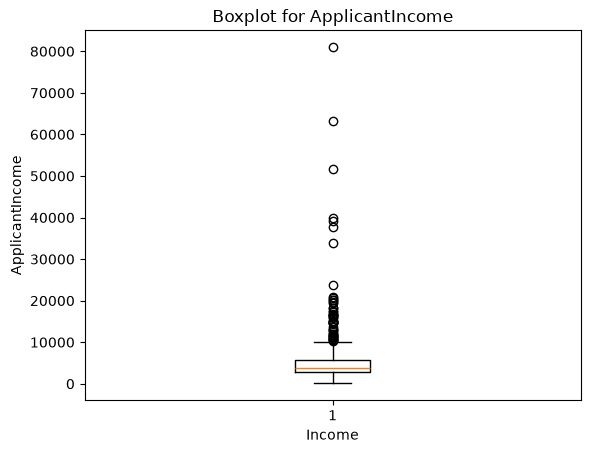

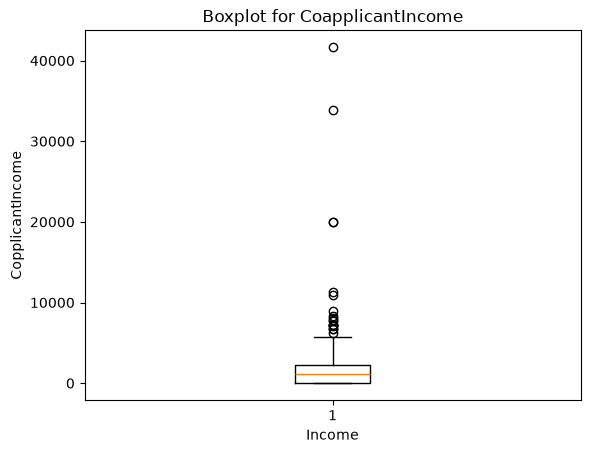

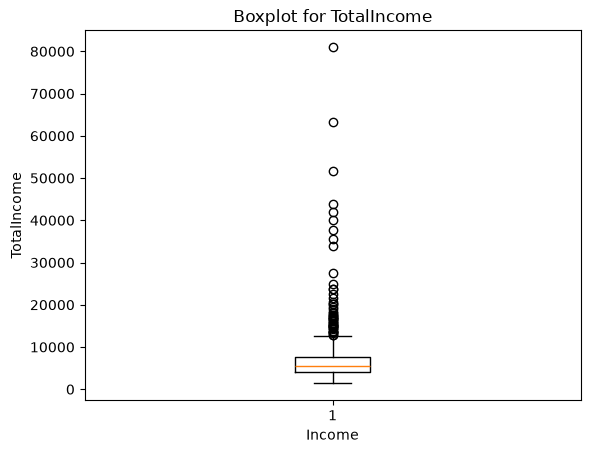

ApplicntINcome, CoapplicantIncome and TotalIncome shows allot of outliers outside the normal quatile range, We will have to then find a way to fix this


In [78]:
#Handling outliers on ApplicantIncome , CoapplicantIncome and Totalincome
#Detecting outliers

plt.boxplot(df["ApplicantIncome"])
plt.title("Boxplot for ApplicantIncome")
plt.xlabel("Income")
plt.ylabel("ApplicantIncome")
plt.show()


#coapplicantincome
plt.boxplot(df["CoapplicantIncome"])
plt.title("Boxplot for CoapplicantIncome")
plt.xlabel("Income")
plt.ylabel("CopplicantIncome")

plt.show()

#totalincome
plt.boxplot(df["TotalIncome"])
plt.title("Boxplot for TotalIncome")
plt.xlabel("Income")
plt.ylabel("TotalIncome")


plt.show()
print(f"ApplicntINcome, CoapplicantIncome and TotalIncome shows allot of outliers outside the normal quatile range, We will have to then find a way to fix this")



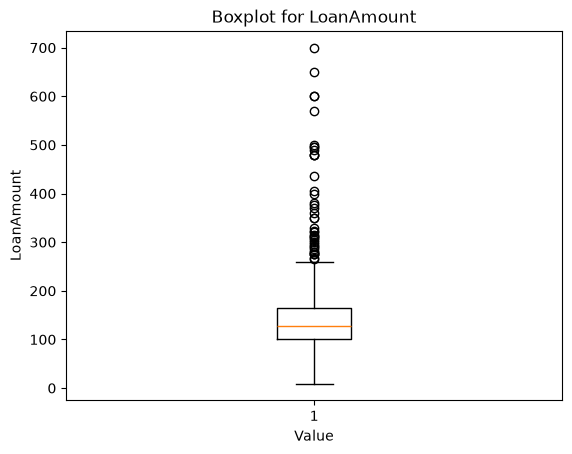

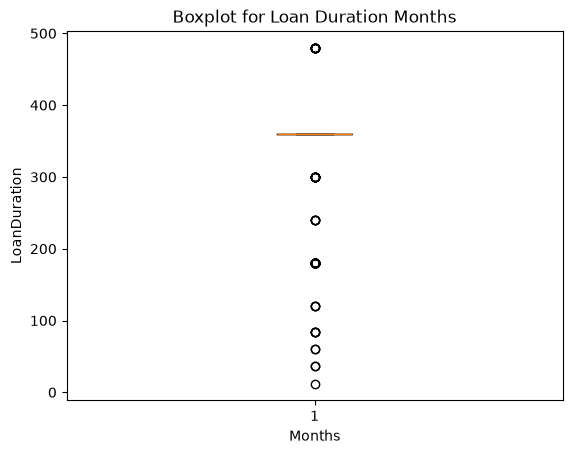

In [79]:
#Detect outliers for Loan Amount and Loan Amount Duration
plt.boxplot(df["LoanAmount"])
plt.title("Boxplot for LoanAmount")
plt.xlabel("Value")
plt.ylabel("LoanAmount")
plt.show()


plt.boxplot(df["LoanDurationMonths"])
plt.title("Boxplot for Loan Duration Months")
plt.xlabel("Months")
plt.ylabel("LoanDuration")
plt.show()


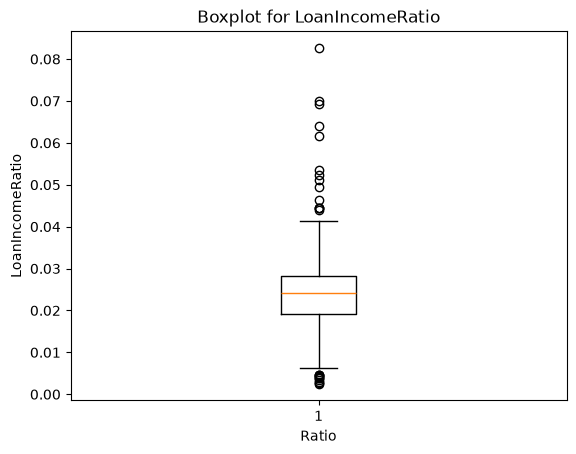

In [80]:
#Detect outliers for LoanIncomeRatio
plt.boxplot(df["LoanIncomeRatio"])
plt.title("Boxplot for LoanIncomeRatio")
plt.xlabel("Ratio")
plt.ylabel("LoanIncomeRatio")
plt.show()

In [81]:
#Handling outliers for applicantIncome, coapplicantincome, loan duration months, loan amount, totalincome, loanincomeratio
# USING IQR method
# #Applicantincome

Q1 = df["ApplicantIncome"].quantile(0.25)
Q3 = df["ApplicantIncome"].quantile(0.75)

IQR = Q3 - Q1
lower_Q = Q1 - 1.5 * IQR
upper_Q = Q3 + 1.5 * IQR

appInc_outliers = df[
    (df["ApplicantIncome"] < lower_Q) |
    (df["ApplicantIncome"] > upper_Q)
]

appInc_outliers["ApplicantIncome"]

df["ApplicantIncome"] = np.clip( df["ApplicantIncome"],
    lower_Q,
    upper_Q
)

In [82]:
#Handling outliers for applicantIncome, coapplicantincome, loan duration months, loan amount, totalincome, loanincomeratio
# USING IQR method
# #Coapplicantincome

Q1_c = df["CoapplicantIncome"].quantile(0.25)
Q3_c = df["CoapplicantIncome"].quantile(0.75)

IQR = Q3_c - Q1_c
lower_Q_c = Q1_c - 1.5 * IQR
upper_Q_c = Q3_c + 1.5 * IQR

CoInc_outliers = df[
    (df["CoapplicantIncome"] < lower_Q_c) |
    (df["CoapplicantIncome"] > upper_Q_c)
]

CoInc_outliers["CoapplicantIncome"]

df["CoapplicantIncome"] = np.clip( df["CoapplicantIncome"],
    lower_Q_c,
    upper_Q_c
)


In [83]:
#Handling outliers for applicantIncome, coapplicantincome, loan duration months, loan amount, totalincome, loanincomeratio
# USING IQR method
# #Totalincome

Q1_t = df["TotalIncome"].quantile(0.25)
Q3_t = df["TotalIncome"].quantile(0.75)

IQR = Q3_t - Q1_t
lower_Q_t = Q1_t - 1.5 * IQR
upper_Q_t = Q3_t + 1.5 * IQR

ToInc_outliers = df[
    (df["TotalIncome"] < lower_Q_t) |
    (df["TotalIncome"] > upper_Q_t)
]

ToInc_outliers["TotalIncome"]

df["TotalIncome"] = np.clip( df["TotalIncome"],
    lower_Q_t,
    upper_Q_t
)

In [84]:
#Handling outliers for applicantIncome, coapplicantincome, totalincome, loan duration months, loan amount, loanincomeratio
# USING IQR method
# LoanAmount

Q1_l = df["LoanAmount"].quantile(0.25)
Q3_l = df["LoanAmount"].quantile(0.75)

IQR = Q3_l - Q1_l
lower_Q_l = Q1_l - 1.5 * IQR
upper_Q_l = Q3_l + 1.5 * IQR

LoAm_outliers = df[
    (df["LoanAmount"] < lower_Q_l) |
    (df["LoanAmount"] > upper_Q_l)
]

LoAm_outliers["LoanAmount"]

df["LoanAmount"] = np.clip( df["LoanAmount"],
    lower_Q_l,
    upper_Q_l
)

In [85]:
#Handling outliers for applicantIncome, coapplicantincome, totalincome, loan duration months, loan amount, loanincomeratio
# USING IQR method
# LoanRatio

Q1_rl = df["LoanIncomeRatio"].quantile(0.25)
Q3_rl = df["LoanIncomeRatio"].quantile(0.75)

IQR = Q3_rl - Q1_rl
lower_Q_rl = Q1_rl - 1.5 * IQR
upper_Q_rl = Q3_rl + 1.5 * IQR

LoInc_outliers = df[
    (df["LoanIncomeRatio"] < lower_Q_rl) |
    (df["LoanIncomeRatio"] > upper_Q_rl)
]

LoInc_outliers["LoanIncomeRatio"]

df["LoanIncomeRatio"] = np.clip( df["LoanIncomeRatio"],
    lower_Q_l,
    upper_Q_l
)

Standarddisation 

Robustscaler is usefull for these columns or variables because these variables have varying datapoints and they may have allot of outliers hence robust is the best scaler for these variables or features

Standardsclaer is best suited for Loan Duration Months

In [86]:
#Standarddisation 
#Robustscaler is usefull for these columns or variables because these variables have varying datapoints and they may have allot of outliers hence robust is the best scaler for these variables or features
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler

scaler = RobustScaler()
df["ApplicantIncome"] = scaler.fit_transform(df[["ApplicantIncome"]])

df["CoapplicantIncome"] = scaler.fit_transform(df[["CoapplicantIncome"]])

df["LoanAmount"] = scaler.fit_transform(df[["LoanAmount"]])

scaler = StandardScaler()
df["LoanDurationMonths"] = scaler.fit_transform(df[["LoanDurationMonths"]])

#Standarddisation of new features Totalincome and LoanRatio

scaler = RobustScaler()
df["TotalIncome"] = scaler.fit_transform(df[["TotalIncome"]])

df["LoanIncomeRatio"] = scaler.fit_transform(df[["LoanIncomeRatio"]])


In [87]:
df

#df.to_csv("ML_Dataset_allfeatures.csv", index=False)

,Gender,Married,Dependents,Graduated,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanDurationMonths,Credit_Score,Loan_Status,TotalIncome,LoanIncomeRatio,Area_Type_Rural,Area_Type_Semiurban,Area_Type_Urban
0,1,0,0,0,0,0.698029,-0.517358,0.000000,0.273231,1,1,0.128883,0.0,0,0,1
1,1,1,1,0,0,0.264096,0.139079,0.000000,0.273231,1,0,0.200998,0.0,1,0,0
2,1,1,0,0,1,-0.278492,-0.517358,-0.961240,0.273231,1,1,-0.720107,0.0,0,0,1
3,1,1,0,1,0,-0.421422,0.509087,-0.124031,0.273231,1,1,-0.141697,0.0,0,0,1
4,1,0,0,0,0,0.749786,-0.517358,0.201550,0.273231,1,1,0.173881,0.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,-0.312768,-0.517358,-0.883721,0.273231,1,1,-0.749907,0.0,1,0,0
610,1,1,3,0,0,0.100600,-0.517358,-1.364341,-2.522836,1,1,-0.390524,0.0,1,0,0
611,1,1,1,0,0,1.459983,-0.412885,1.937984,0.273231,1,1,0.862847,0.0,0,0,1
612,1,1,2,0,0,1.292374,-0.517358,0.914729,0.273231,1,1,0.645608,0.0,0,0,1


Checking correlation

Correlation will help us dictate which variables are worth using for Machine learning and which do not correlate with LoanStatus

In [88]:

df.corr(numeric_only=True)["Loan_Status"].sort_values(ascending=False)

#print(f" from the looks of things, the top 4 variables which have a high correlation is Credit_Score, Area_Type_Semiurban, Married and Gender the other negatively strong variables are Area_Type_Rural")

Loan_Status            1.000000
Credit_Score           0.540556
Area_Type_Semiurban    0.136540
Married                0.096657
Gender                 0.017987
CoapplicantIncome      0.011983
Dependents             0.010118
TotalIncome            0.002220
ApplicantIncome       -0.000442
Self_Employed         -0.003700
LoanDurationMonths    -0.022549
Area_Type_Urban       -0.043621
LoanAmount            -0.047262
Graduated             -0.085884
Area_Type_Rural       -0.100694
LoanIncomeRatio             NaN
Name: Loan_Status, dtype: float64

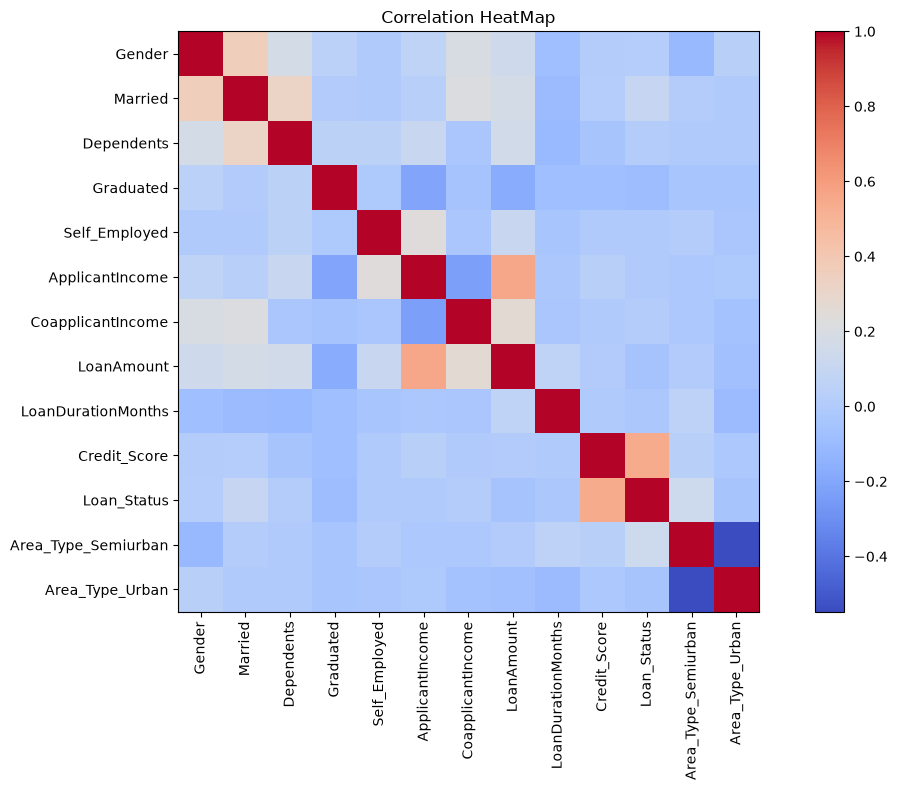

In [92]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)


plt.title("Correlation HeatMap")
plt.tight_layout()
plt.show()



Features which would work best for Machine learning and features which wont work
Top 6 best feautures would be
- Credit Score which is 0.540
- Area_Type_Semiurban   0.136
- Married               0.096
- Gender                0.018
- CoapplicantIncome     0.012
- Dependents            0.010

Since ApplicantIncome, Coapplicantincome and TotalIncome are vital for business to make a decision on the final outcome we shall include it because it is very much relevant for the buiness predictive loan model we trying to do.

TotalIncome shall be removed because totalincome is included in both the income columns

In [90]:
#Final Machine learning set

df = df.drop(
columns=["TotalIncome",
 "LoanIncomeRatio",
 "Area_Type_Rural"])

df.to_csv("Final ML Dataset.csv", index=False)